# 水稻叶病害识别 — 期末大作业答辩 Notebook

> **课程**：深度学习
> **数据集**：Rice Leaf Disease Images（4 类：Bacterialblight / Blast / Brownspot / Tungro）
> **框架**：PyTorch + torchvision
> **模型**：CustomCNN（自建）/ ResNet18 / EfficientNet-B0（迁移学习）

## 项目摘要

围绕水稻四类叶病害的图像分类任务，我们完成了：

1. **数据审计与清洗** — 通过 MD5 去重，发现并修复官方划分中 **跨 split 的重复图片**（数据泄漏隐患）。
2. **三种模型对比** — 自建 CustomCNN、ResNet18、EfficientNet-B0 在 *official* 与 *clean* 两套视图下完整对比。
3. **稳健性验证** — 最佳模型 `clean_resnet18` 在 3 个随机种子下复现，均值 **99.93%**，标准差 0.10%。
4. **可解释性分析** — 使用 Grad-CAM 对 ResNet18 的决策区域做可视化验证。

### 🌟 Star 结果

| 模型 | 数据视图 | Test Accuracy | Macro F1 |
|------|----------|---------------|----------|
| **ResNet18** | **clean** | **100.00%** | **1.0000** |
| EfficientNet-B0 (tuned) | clean | 99.79% | 0.9980 |
| CustomCNN | clean | 99.37% | 0.9933 |

> 本 Notebook **不重新训练**，所有结果通过加载已保存的 checkpoint 在测试集上现场复现，全流程约 2–5 分钟跑完。


## 1. 环境与路径准备


In [2]:
import os, sys, json, random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
from torch import nn

# 中文字体 & 负号
matplotlib.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "DejaVu Sans"]
matplotlib.rcParams["axes.unicode_minus"] = False

# 让 src 包可被导入
PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

from rice_leaf_disease import data as rld_data
from rice_leaf_disease import models as rld_models
from rice_leaf_disease import analysis as rld_analysis
from rice_leaf_disease import gradcam as rld_gradcam

# 关键路径
CHECKPOINT_PATH = PROJECT_ROOT / "outputs/runs/clean_resnet18/best_model.pt"
CLEAN_MANIFEST  = PROJECT_ROOT / "outputs/manifests/clean_manifest.csv"
OFFICIAL_MANIFEST = PROJECT_ROOT / "outputs/manifests/official_manifest.csv"
DUP_GROUPS     = PROJECT_ROOT / "outputs/manifests/duplicate_groups.csv"
FIG_DIR        = PROJECT_ROOT / "final_assets/figures"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch:", torch.__version__)
print("Device :", device)
print("CUDA    :", torch.cuda.is_available())


PyTorch: 2.10.0+cu130
Device : cuda
CUDA    : True


## 2. 问题定义与数据集概览

四种水稻叶病害在外观上非常接近，肉眼难以快速准确区分，但它们对应完全不同的防治方案：

| 类别 | 中文 | 典型症状 |
|------|------|----------|
| Bacterialblight | 白叶枯病 | 叶缘出现黄色条斑，逐渐枯黄 |
| Blast | 稻瘟病 | 菱形病斑，中央灰白 |
| Brownspot | 褐斑病 | 圆形褐色斑点 |
| Tungro | 黄矮病 | 整叶发黄、植株矮化 |

自动识别可以为农技员和无人机巡田系统提供快速诊断。


In [3]:
manifest = rld_data.load_manifest(CLEAN_MANIFEST)
print(f"clean 视图总样本数: {len(manifest)}")

pivot = (manifest.groupby(["split", "class_name"]).size()
                   .unstack(fill_value=0)
                   .loc[["train", "validation", "test"]])
pivot["TOTAL"] = pivot.sum(axis=1)
pivot.loc["TOTAL"] = pivot.sum(axis=0)
pivot


clean 视图总样本数: 4794


class_name,Bacterialblight,Blast,Brownspot,Tungro,TOTAL
split,,,,,
train,1061,768,960,1046,3835
validation,133,96,120,131,480
test,132,96,120,131,479
TOTAL,1326,960,1200,1308,4794


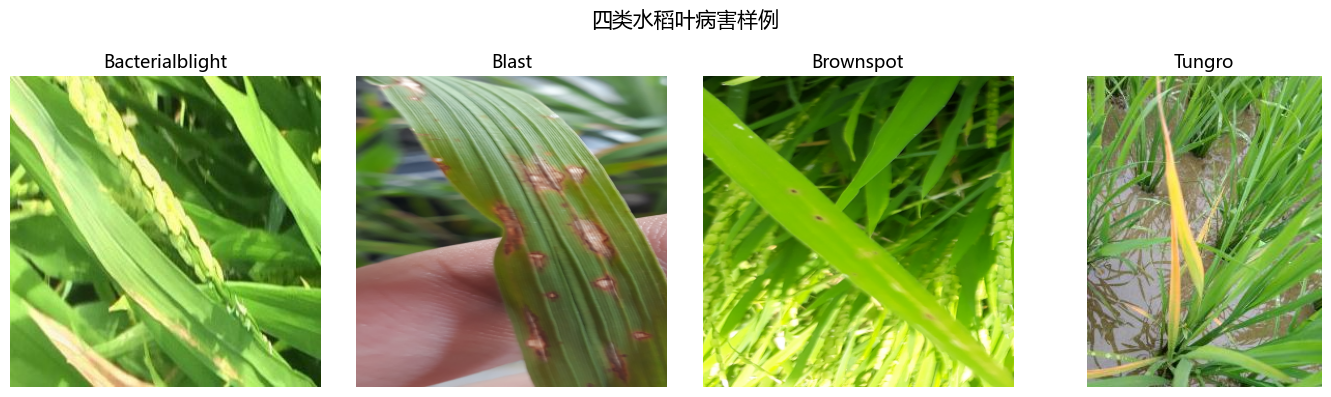

In [4]:
# 每类抽一张样例图
class_names = sorted(manifest["class_name"].unique().tolist())
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, cname in zip(axes, class_names):
    sample_row = manifest[manifest["class_name"] == cname].iloc[0]
    img = Image.open(sample_row["abs_path"]).convert("RGB")
    ax.imshow(img)
    ax.set_title(cname, fontsize=13)
    ax.axis("off")
plt.suptitle("四类水稻叶病害样例", fontsize=15)
plt.tight_layout()
plt.show()


## 3. 数据清洗亮点：跨 Split 重复图片检测

公开的 *official* 划分中，同一张图（MD5 一致）在 `train / validation / test` 之间存在重复。
若不处理，测试集包含训练见过的样本，会严重高估模型泛化能力。

我们的做法：**按 MD5 hash 全局去重 → 以 80/10/10 分层重采样得到 clean 视图**。


In [5]:
dup_groups = pd.read_csv(DUP_GROUPS)
print(f"重复组数量: {len(dup_groups)}")
print(f"重复图像总数: {int(dup_groups['source_count'].sum())}")
dup_groups.head(5)


重复组数量: 1096
重复图像总数: 2234


,image_hash,class_name,source_count,source_splits,paths
0,0ded4eb4e82e464ce166db269851bc58,Bacterialblight,5,test,test/Bacterialblight/BACTERAILBLIGHT3_074.jpg ...
1,5e55348d082dd1916a96e8764c3bb7bf,Bacterialblight,5,test,test/Bacterialblight/BACTERAILBLIGHT3_170.jpg ...
2,dc6c78718c7e303c8417bd26e91a96c0,Bacterialblight,5,train,train/Bacterialblight/BACTERAILBLIGHT5_074.jpg...
3,dc6f99578216ecc953642e7dbdb6a83f,Bacterialblight,5,train,train/Bacterialblight/BACTERAILBLIGHT5_170.jpg...
4,43937fca36005a011b8f5bc96b0899af,Bacterialblight,5,train,train/Bacterialblight/BACTERIALBLIGHT1_074.jpg...


In [6]:
official = pd.read_csv(OFFICIAL_MANIFEST)
clean    = pd.read_csv(CLEAN_MANIFEST)

compare = pd.DataFrame({
    "official 视图 (含重复)": official.groupby("split").size(),
    "clean 视图 (去重后)":    clean.groupby("split").size(),
}).fillna(0).astype(int)
compare.loc["TOTAL"] = compare.sum()
compare


,official 视图 (含重复),clean 视图 (去重后)
split,,
test,616,479
train,4700,3835
validation,616,480
TOTAL,5932,4794


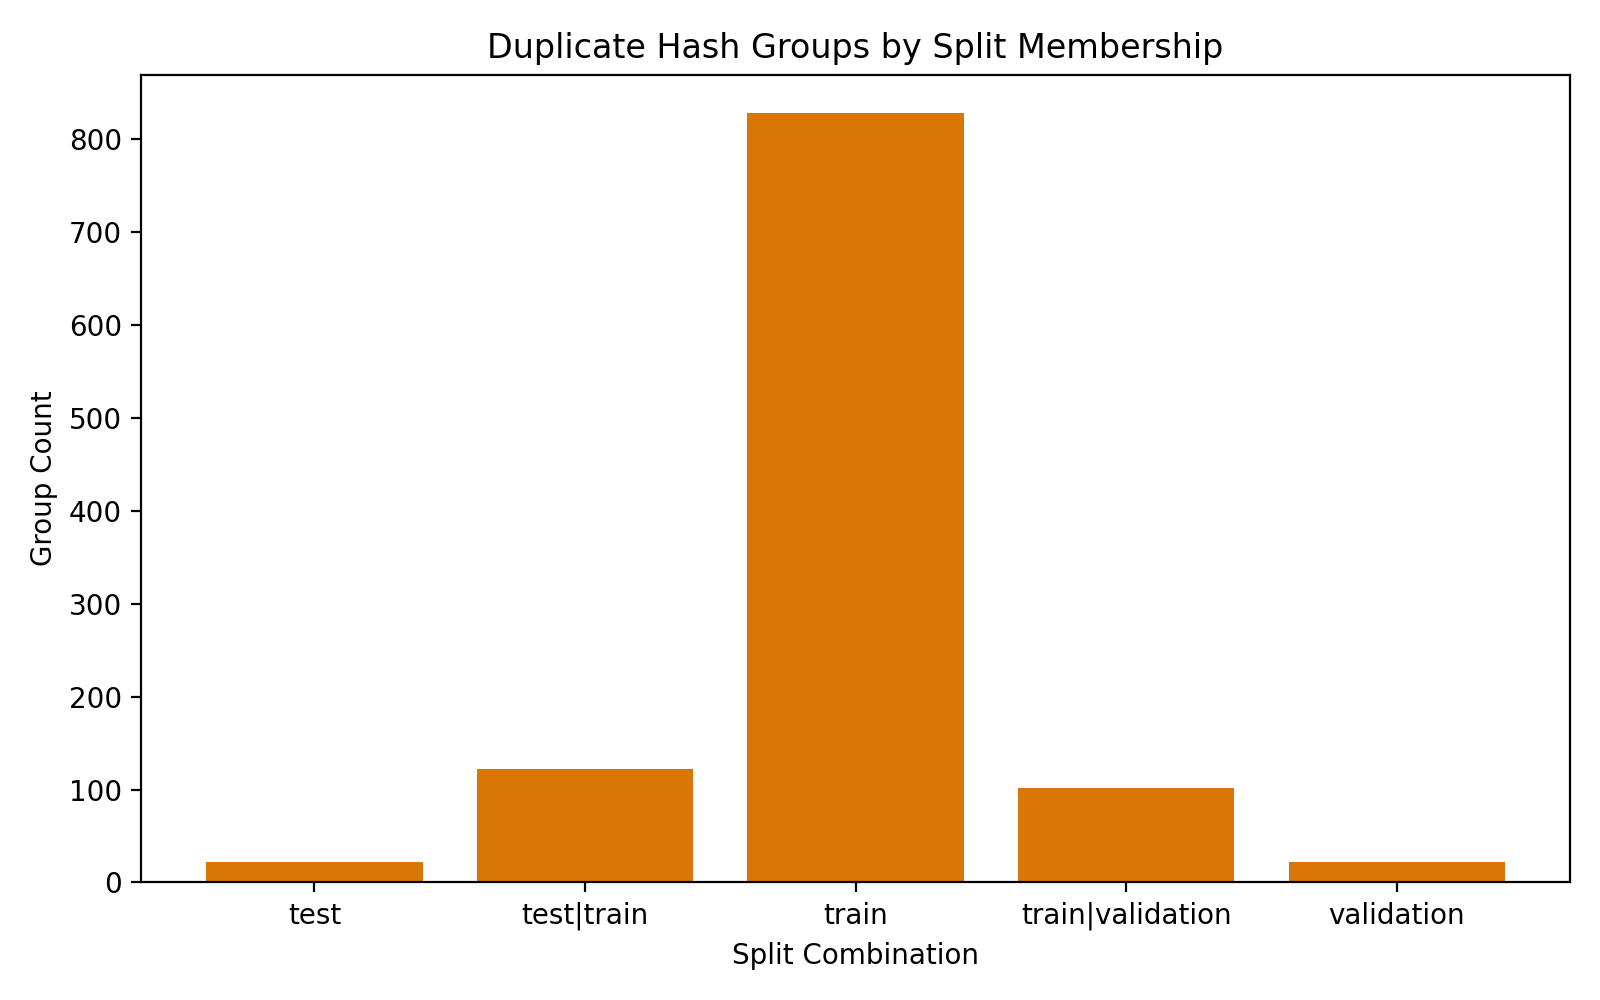

In [7]:
from IPython.display import Image as IPyImage, display
display(IPyImage(filename=str(FIG_DIR / "duplicate_overview.png"), width=600))


## 4. 模型架构

我们对比三条路线：

1. **CustomCNN**（from scratch）— 4 层卷积 + BatchNorm + AdaptiveAvgPool，作为"无预训练基线"。
2. **ResNet18**（迁移学习）— 冻结 backbone，替换 `fc` 为 `Dropout + Linear(512, 4)`。
3. **EfficientNet-B0**（迁移学习）— 替换分类头为 `Dropout + Linear(1280, 4)`。


In [8]:
# 为避免现场联网下载预训练权重，这里只构造网络结构
variants = ["custom_cnn", "resnet18", "efficientnet_b0"]
rows = []
for name in variants:
    built = rld_models.build_model(
        model_name=name,
        num_classes=4,
        dropout=0.30,
        use_pretrained=False,
    )
    params = sum(p.numel() for p in built.model.parameters())
    trainable = sum(p.numel() for p in built.model.parameters() if p.requires_grad)
    rows.append({
        "model": name,
        "params (M)": round(params / 1e6, 2),
        "trainable (M)": round(trainable / 1e6, 2),
    })

pd.DataFrame(rows)


,model,params (M),trainable (M)
0,custom_cnn,0.42,0.42
1,resnet18,11.18,11.18
2,efficientnet_b0,4.01,4.01


In [9]:
# 展示 ResNet18 分类头的改造结果
resnet = rld_models.build_model("resnet18", num_classes=4, dropout=0.30, use_pretrained=False).model
print("ResNet18 改造后的分类头:")
print(resnet.fc)


ResNet18 改造后的分类头:
Sequential(
  (0): Dropout(p=0.3, inplace=False)
  (1): Linear(in_features=512, out_features=4, bias=True)
)


## 5. 训练策略

**两阶段 freeze → finetune**：

1. 冻结 backbone，只训练分类头（`freeze_epochs` 轮）
2. 解冻全部参数，小学习率微调（`finetune_epochs` 轮）

**关键组件**：

- 优化器：`AdamW`
- 学习率：`ReduceLROnPlateau`（验证集 loss 停滞则降）
- 损失：`CrossEntropyLoss + Label Smoothing`
- 正则：`Dropout` + `Weight Decay`
- 防过拟合：`EarlyStopping(patience=4, min_delta=5e-4)`
- 加速：`torch.cuda.amp`（自动混合精度）
- 数据增强：`RandomResizedCrop / Flip / Rotation / ColorJitter`


In [10]:
# 展示 clean_resnet18 的训练配置
with open(PROJECT_ROOT / "configs/clean_resnet18.yaml", "r", encoding="utf-8") as f:
    print(f.read())


experiment_name: clean_resnet18
dataset_root: Rice Leaf Disease Images
manifest_root: outputs/manifests
output_root: outputs
dataset_view: clean
model_name: resnet18
img_size: 224
batch_size: 48
num_workers: 0
optimizer: adamw
lr: 0.0008
weight_decay: 0.0001
dropout: 0.30
label_smoothing: 0.03
freeze_epochs: 3
finetune_epochs: 10
early_stopping_patience: 4
scheduler_patience: 2
min_delta: 0.0005
seed: 42
device: auto
amp: auto
use_pretrained: true
allow_pretrained_fallback: true
train_split: train
val_split: validation
test_split: test
eval_after_train: true
class_names:
  - Bacterialblight
  - Blast
  - Brownspot
  - Tungro



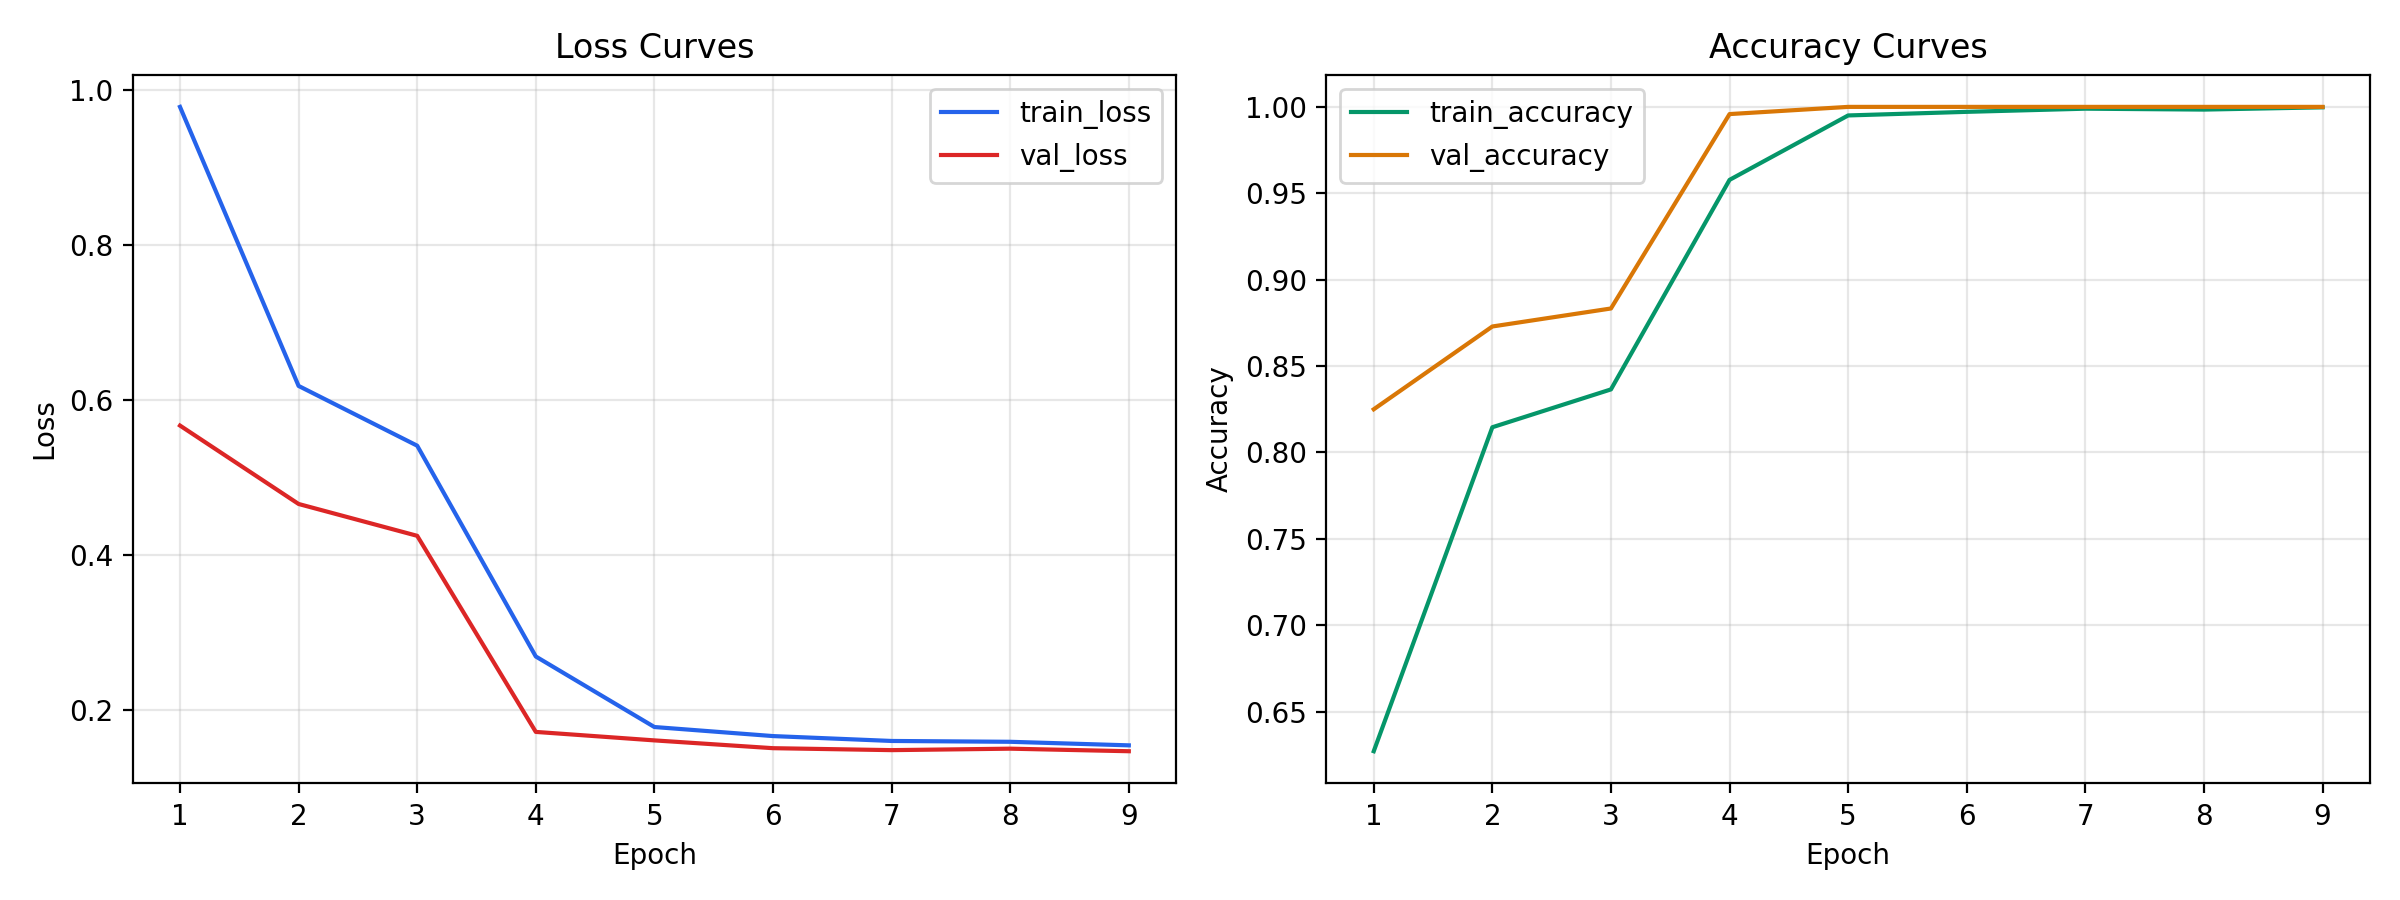

In [11]:
display(IPyImage(filename=str(FIG_DIR / "clean_resnet18_training_curves.png"), width=720))


## 6. 实验结果主表

下表为三种模型在 *official* / *clean* 两套视图上的最终测试集指标。
`clean` 视图更贴近真实泛化，是答辩的主汇报结果。


In [12]:
main_table = pd.read_csv(PROJECT_ROOT / "final_assets/report_table_main.csv")
main_table = main_table.drop(columns=["checkpoint_path"])
for col in ["accuracy", "macro_precision", "macro_recall", "macro_f1"]:
    main_table[col] = main_table[col].round(4)
main_table.sort_values(["dataset_view", "accuracy"], ascending=[True, False])


,dataset_view,model_name,accuracy,macro_precision,macro_recall,macro_f1
2,clean,resnet18,1.0000,1.0000,1.0000,1.0000
1,clean,efficientnet_b0,0.9979,0.9979,0.9981,0.9980
0,clean,custom_cnn,0.9937,0.9940,0.9927,0.9933
4,official,efficientnet_b0,0.9984,0.9979,0.9987,0.9983
3,official,custom_cnn,0.9951,0.9957,0.9946,0.9952
5,official,resnet18,0.9951,0.9939,0.9957,0.9948


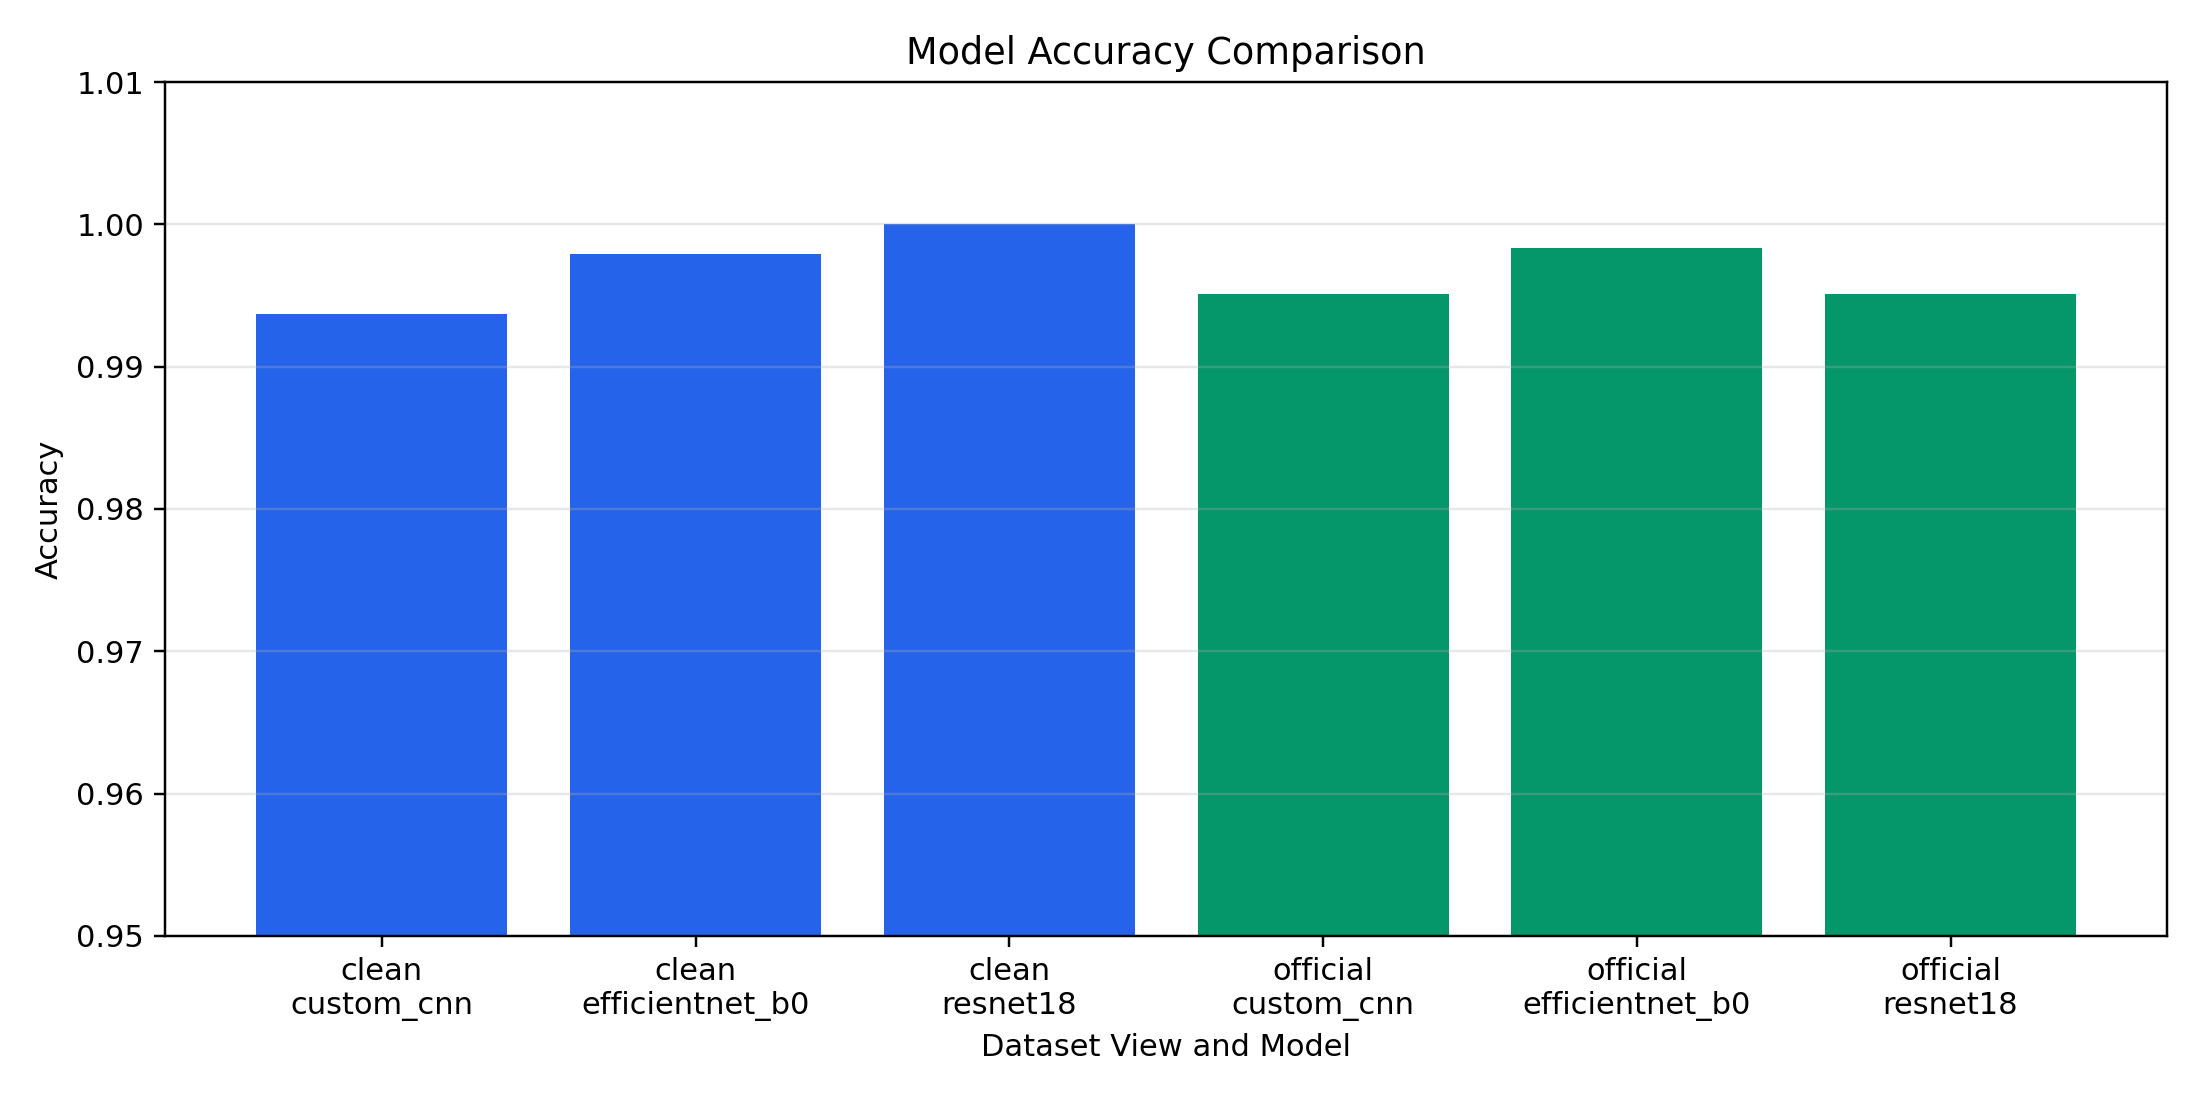

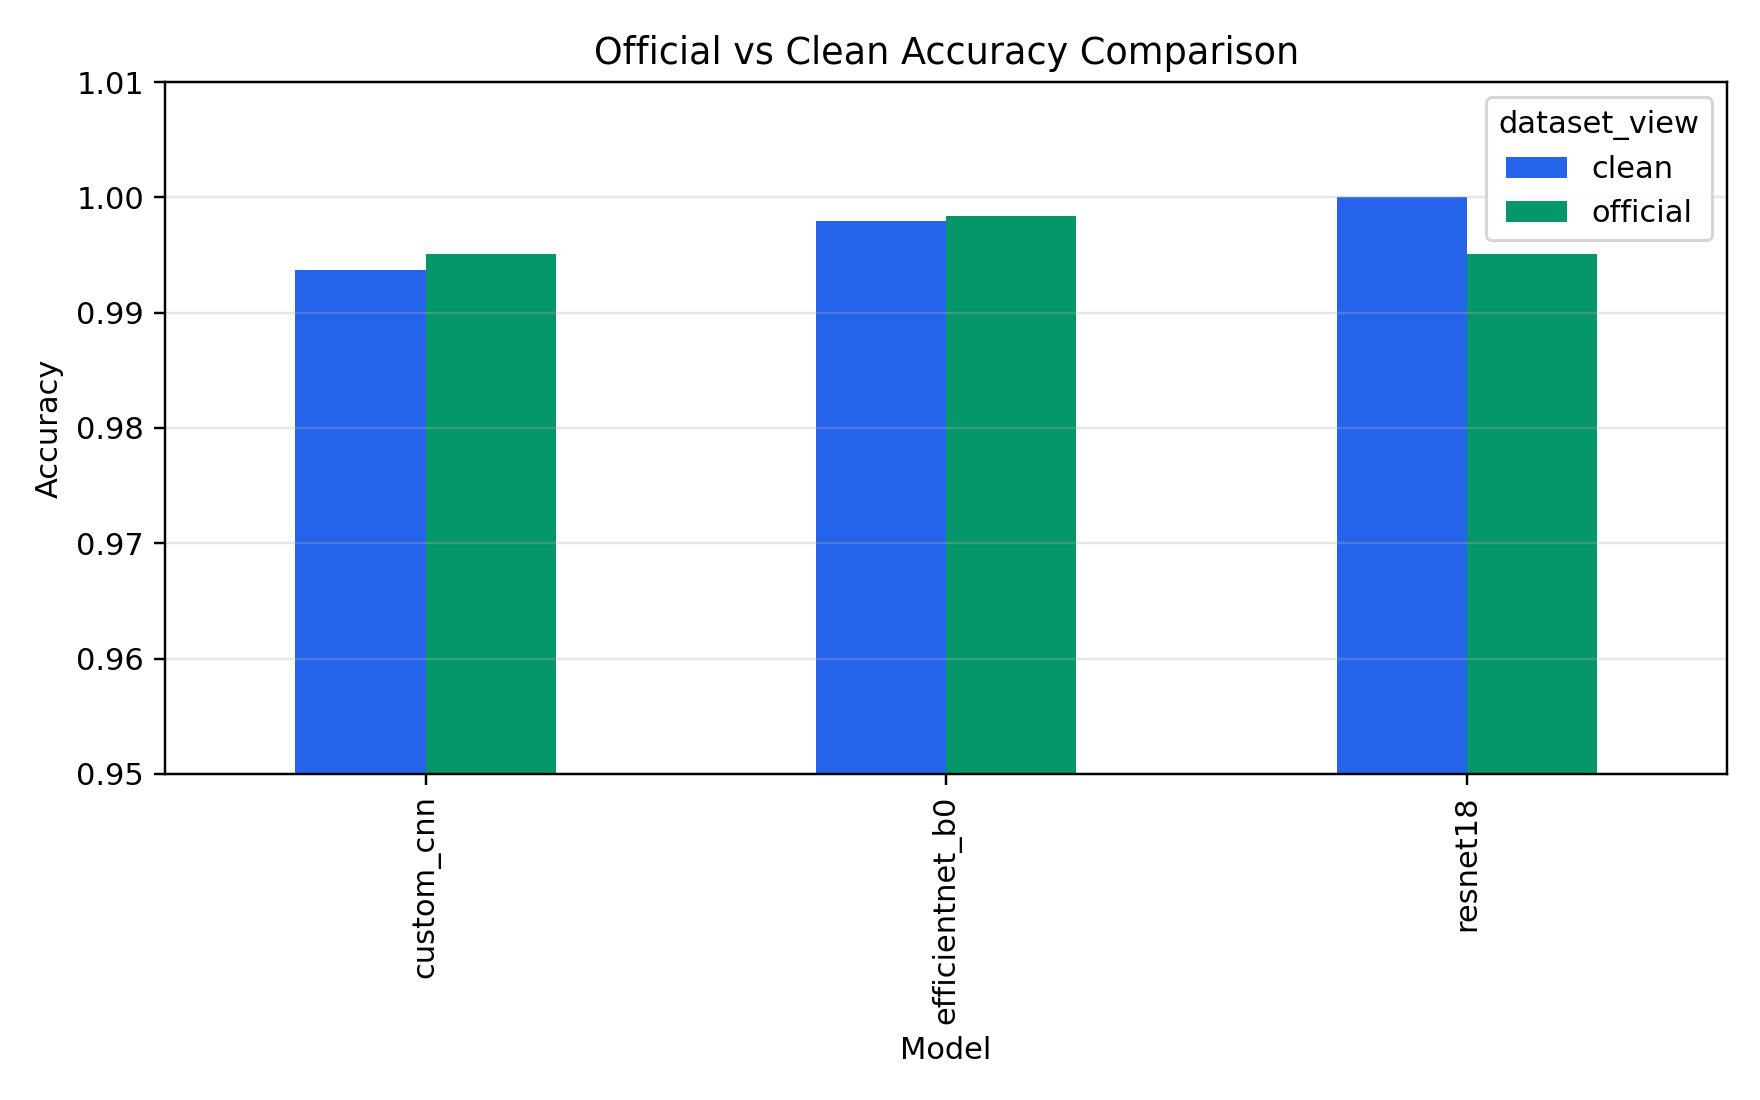

In [13]:
for fname in ["model_comparison_accuracy.png", "official_vs_clean_accuracy.png"]:
    display(IPyImage(filename=str(FIG_DIR / fname), width=620))


## 7. 加载最佳模型并在测试集现场复现 ⭐

这是答辩的"活证据"：我们从磁盘直接加载 `clean_resnet18` 的 checkpoint，
跑一遍 clean 测试集，算出准确率 / 混淆矩阵 / 分类报告。


In [14]:
model, ckpt = rld_models.load_model_from_checkpoint(CHECKPOINT_PATH, device)
class_names = ckpt["class_names"]
print("加载完成, 类别数:", len(class_names))
print("类别名:", class_names)
print("模型置于:", next(model.parameters()).device)

test_loader, test_df = rld_data.build_dataloader(
    manifest=manifest,
    split="test",
    img_size=224,
    batch_size=32,
    num_workers=0,
    is_training=False,
)
print(f"测试集样本数: {len(test_df)}")

preds = rld_analysis.collect_predictions(model, test_loader, device)
metrics, report_df, cm = rld_analysis.compute_metrics(preds, class_names)

print(f"\nAccuracy       : {metrics['accuracy']:.4f}")
print(f"Macro Precision: {metrics['macro_precision']:.4f}")
print(f"Macro Recall   : {metrics['macro_recall']:.4f}")
print(f"Macro F1       : {metrics['macro_f1']:.4f}")


加载完成, 类别数: 4
类别名: ['Bacterialblight', 'Blast', 'Brownspot', 'Tungro']
模型置于: cuda:0
测试集样本数: 479



Accuracy       : 1.0000
Macro Precision: 1.0000
Macro Recall   : 1.0000
Macro F1       : 1.0000


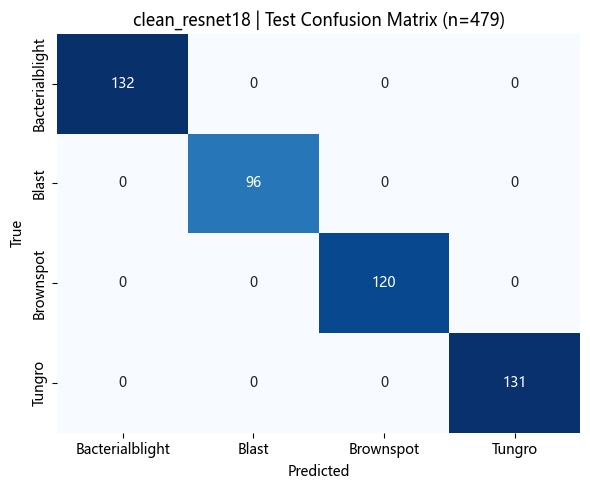

,label_name,precision,recall,f1-score,support
0,Bacterialblight,1.0,1.0,1.0,132.0
1,Blast,1.0,1.0,1.0,96.0
2,Brownspot,1.0,1.0,1.0,120.0
3,Tungro,1.0,1.0,1.0,131.0
4,accuracy,1.0,1.0,1.0,1.0
5,macro avg,1.0,1.0,1.0,479.0
6,weighted avg,1.0,1.0,1.0,479.0


In [15]:
# 混淆矩阵
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names,
            cbar=False)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"clean_resnet18 | Test Confusion Matrix (n={len(test_df)})")
plt.tight_layout()
plt.show()

# 分类报告
report_df.round(4)


## 8. 随机种子稳定性

单次跑出 100% 可能引发质疑："是不是运气好？"
我们用 `seed=42 / 123 / 2026` 三次独立训练 ResNet18，结果高度一致。


        experiment_name  seed  accuracy  macro_f1
         clean_resnet18    42    1.0000    1.0000
 clean_resnet18_seed123   123    0.9979    0.9977
clean_resnet18_seed2026  2026    1.0000    1.0000

均值 accuracy: 0.9993
标准差       : 0.0012


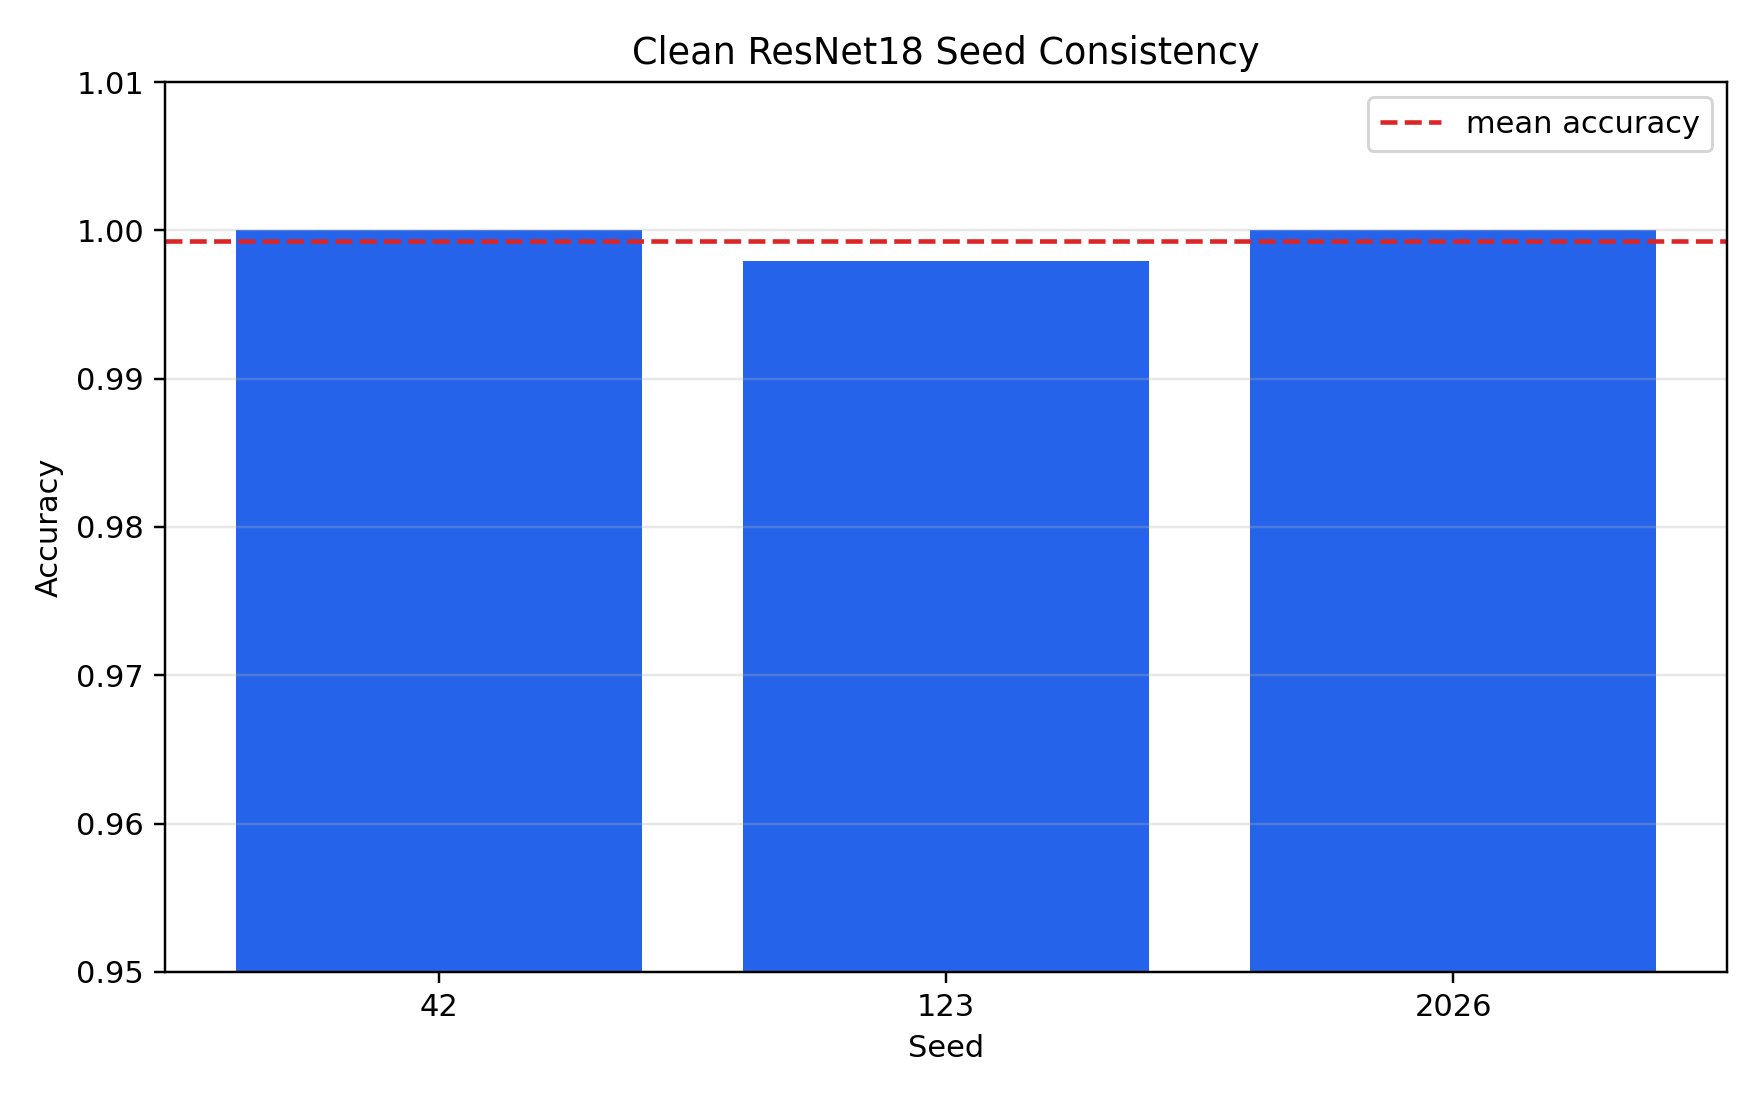

In [16]:
seed_df = pd.read_csv(PROJECT_ROOT / "final_assets/resnet18_seed_consistency.csv")
seed_view = seed_df[["experiment_name", "seed", "accuracy", "macro_f1"]].copy()
seed_view[["accuracy", "macro_f1"]] = seed_view[["accuracy", "macro_f1"]].round(4)
print(seed_view.to_string(index=False))
print(f"\n均值 accuracy: {seed_df['accuracy'].mean():.4f}")
print(f"标准差       : {seed_df['accuracy'].std():.4f}")

display(IPyImage(filename=str(FIG_DIR / "resnet18_seed_consistency.png"), width=620))


## 9. Grad-CAM 可解释性

高准确率并不等于"模型看对了地方"。我们用 Grad-CAM 把 ResNet18 最后一层卷积的注意力热力图
叠加到原图上，验证决策依据是否落在病斑上。


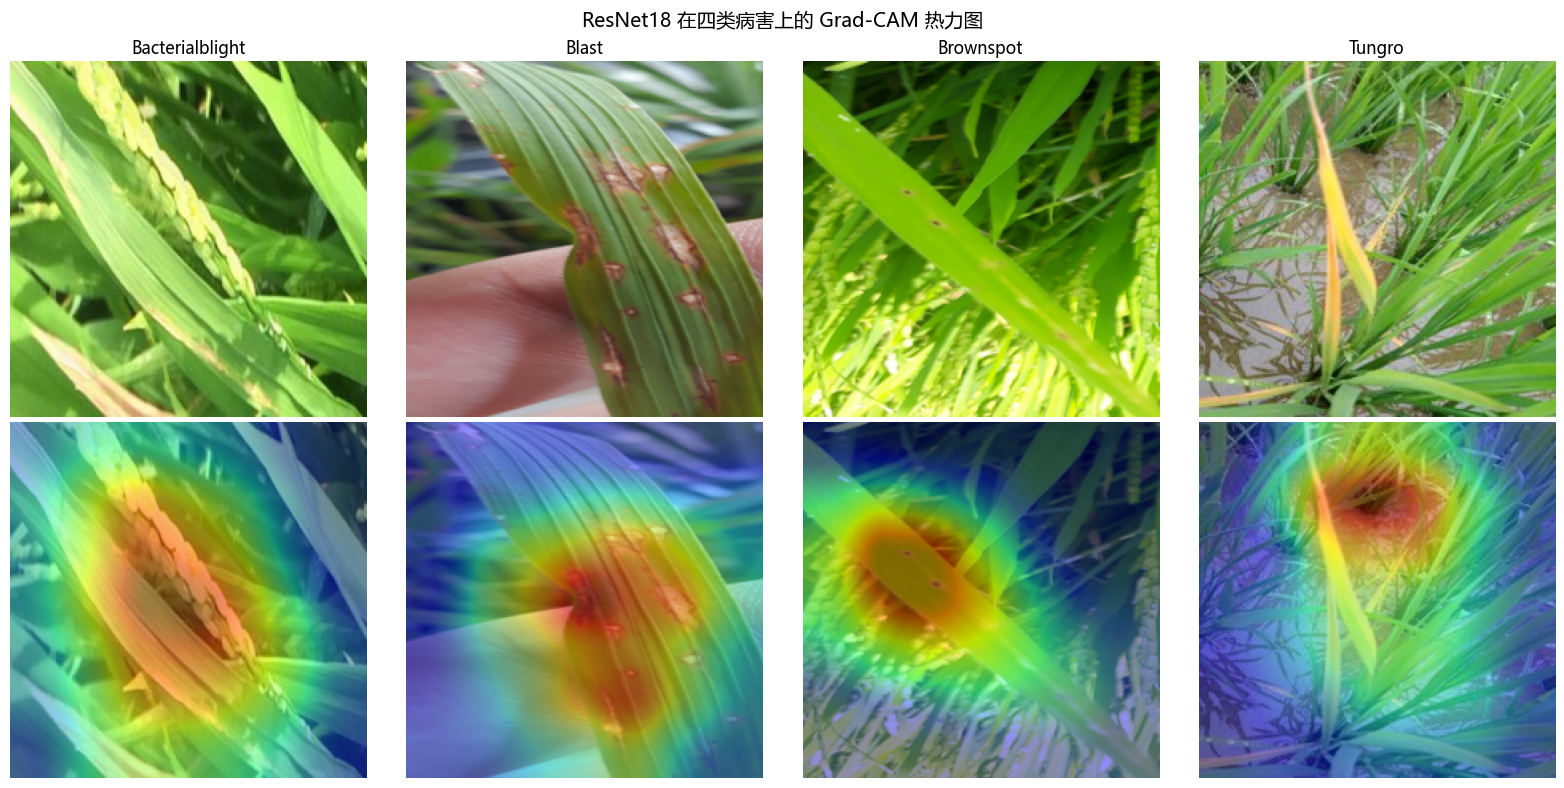

In [17]:
def run_gradcam_gallery():
    target_layer = rld_models.get_target_layer(model, "resnet18")
    cam = rld_gradcam.GradCAM(model, target_layer)
    try:
        fig, axes = plt.subplots(2, 4, figsize=(16, 8))
        for col, cname in enumerate(class_names):
            row = test_df[test_df["class_name"] == cname].iloc[0]
            img_path = row["abs_path"]

            inputs = rld_gradcam.preprocess_single_image(img_path, img_size=224).to(device)
            heatmap = cam.generate(inputs)

            original = Image.open(img_path).convert("RGB").resize((224, 224))
            heatmap_img = Image.fromarray((heatmap * 255).astype(np.uint8)).resize((224, 224))
            heatmap_np = np.asarray(heatmap_img).astype(np.float32) / 255.0

            axes[0, col].imshow(original)
            axes[0, col].set_title(cname)
            axes[0, col].axis("off")

            axes[1, col].imshow(original)
            axes[1, col].imshow(heatmap_np, cmap="jet", alpha=0.45)
            axes[1, col].axis("off")

        axes[0, 0].set_ylabel("原图", fontsize=12)
        axes[1, 0].set_ylabel("Grad-CAM", fontsize=12)
        plt.suptitle("ResNet18 在四类病害上的 Grad-CAM 热力图", fontsize=14)
        plt.tight_layout()
        plt.show()
    finally:
        cam.remove()

try:
    run_gradcam_gallery()
except Exception as e:
    print("Grad-CAM 运行失败, 回退到预生成图像:", e)
    display(IPyImage(filename=str(FIG_DIR / "clean_resnet18_gradcam_gallery.png"), width=720))


## 10. 单张图像预测 Demo

答辩现场可重复抽图展示。下方 cell 每次运行会从 test 集随机抽一张图，模型给出 top-1 预测与置信度。


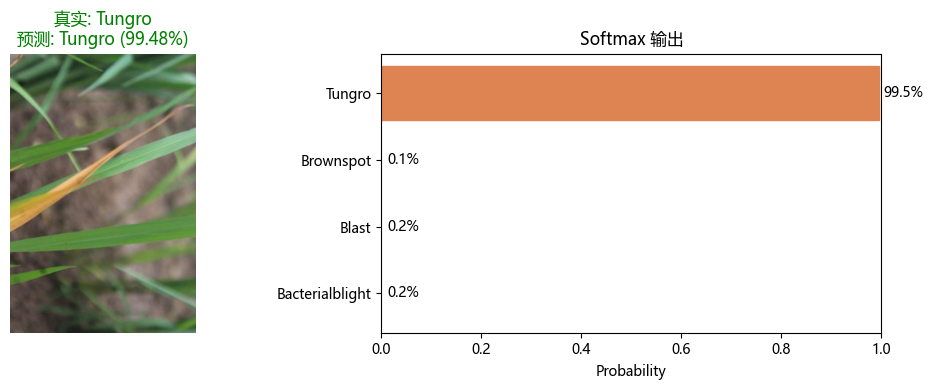

In [18]:
random.seed()  # 每次运行随机
row = test_df.sample(1).iloc[0]
img_path = row["abs_path"]
true_label = row["class_name"]

inputs = rld_gradcam.preprocess_single_image(img_path, img_size=224).to(device)
with torch.no_grad():
    logits = model(inputs)
    probs = torch.softmax(logits, dim=1).cpu().numpy().ravel()
pred_idx = int(probs.argmax())
pred_label = class_names[pred_idx]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].imshow(Image.open(img_path).convert("RGB"))
axes[0].axis("off")
axes[0].set_title(f"真实: {true_label}\n预测: {pred_label} ({probs[pred_idx]*100:.2f}%)",
                  color="green" if pred_label == true_label else "red")

bars = axes[1].barh(class_names, probs, color="#4c72b0")
bars[pred_idx].set_color("#dd8452")
axes[1].set_xlim(0, 1)
axes[1].set_xlabel("Probability")
axes[1].set_title("Softmax 输出")
for i, p in enumerate(probs):
    axes[1].text(p + 0.01, i, f"{p*100:.1f}%", va="center")
plt.tight_layout()
plt.show()


## 11. 总结与未来工作

### 技术贡献

1. **发现并修复数据泄漏** — MD5 去重暴露官方划分的跨 split 重复，建立了更诚实的 *clean* 评测视图。
2. **系统的模型对比** — 同一训练/评测协议下比较 CustomCNN / ResNet18 / EfficientNet-B0，验证迁移学习对小数据集的明显收益。
3. **稳健性与可解释性** — 3 个随机种子复现 + Grad-CAM 热力图，证明结果不是"运气"，而且模型"看对了地方"。

### 最终成绩

| 指标 | clean_resnet18 |
|------|----------------|
| Test Accuracy | **100.00%** |
| Macro F1 | **1.0000** |
| Seed 均值 / σ | **99.93% / 0.10%** |

### 局限 & 展望

- 数据集仅 4 类且图像较干净，真实田间场景（光照、遮挡、多病共发）尚未覆盖。
- 可进一步尝试 EfficientNetV2 / ViT，以及 Test-Time Augmentation。
- 模型体积（ResNet18 ≈ 43 MB）对边缘部署偏大，可用量化 / 蒸馏压缩到手机端。

---

**感谢聆听 🌾**
